1. Install Library

In [44]:
!pip install pandas numpy tensorflow scikit-learn keras wordcloud matplotlib


2. Load dan Encode Data

In [45]:
import pandas as pd

# Load file
file_path = '/content/(8) preprocessing no filtering + indobert 3 kls.xlsx'
df = pd.read_excel(file_path)

# Tampilkan data untuk memastikan
print(df.head())

# Encode label menjadi 0 (negatif), 1 (netral), 2 (positif)
df['label'] = df['label'].map({'negative': 0, 'neutral': 1, 'positive': 2})


   Unnamed: 0                 created_at  \
0           0  2022-01-27 12:29:56+00:00   
1           1  2022-01-27 11:33:49+00:00   
2           2  2022-01-27 09:40:40+00:00   
3           3  2022-01-27 04:39:49+00:00   
4           4  2022-01-27 00:30:58+00:00   

                                           full_text     username  \
0  gpp company lokal asal WFA, mungkin bukan peng...      xyberya   
1  @arifsyh86 @pipis @MrsEuscha @tbputera Sorry b...    ninanenen   
2  Yay nambah opsi baru wfa spot di cibi ????????...      mirzarm   
3  Jadi pelaksana proyek susah kalo wfa. Apalagi ...  segedegabun   
4  tujuan karir sekarang fokusnya lebih ke work l...      favophs   

                                               clean  \
0  gpp company lokal asal wfa mungkin bukan penge...   
1  sorry baru liat notif tidak harus di jakarta k...   
2              yay nambah opsi baru wfa spot di cibi   
3  jadi pelaksana proyek susah kalo wfa apalagi a...   
4  tujuan karir sekarang fokusnya lebih 

3. Split Data untuk Training dan Testing

In [46]:
from sklearn.model_selection import train_test_split

X = df['teks']  # Fitur: kolom teks
y = df['label']  # Label: kolom polaritas

# Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data training: {len(X_train)}")
print(f"Jumlah data testing: {len(X_test)}")


Jumlah data training: 11028
Jumlah data testing: 2757


4. Tokenisasi dan Padding

In [47]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Pastikan data dalam bentuk string
X_train = X_train.astype(str)
X_test = X_test.astype(str)

# Tokenisasi
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

# Ubah teks menjadi urutan angka
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding agar panjangnya seragam
maxlen = 100  # Panjang maksimal setiap teks
X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen, padding='post')


5. Konversi Label ke One-Hot Encoding

In [48]:
from tensorflow.keras.utils import to_categorical

# Konversi label ke one-hot encoding
y_train = to_categorical(y_train, num_classes=3)
y_test = to_categorical(y_test, num_classes=3)


6. Bangun Model CNN-LSTM

In [49]:
from keras.models import Sequential
from keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Dense, Dropout

# Parameter
embedding_dim = 128

# Bangun model
model = Sequential()
model.add(Embedding(input_dim=5000, output_dim=embedding_dim, input_length=maxlen))
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(LSTM(70))
model.add(Dropout(0.5))
model.add(Dense(3, activation='softmax'))  # 3 kelas dengan softmax

# Kompilasi model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Tampilkan ringkasan model
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

7. Train Model

In [50]:
history = model.fit(
    X_train_pad, y_train,
    batch_size=32,
    epochs=10,
    validation_split=0.2,
    verbose=1
)


Epoch 1/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - accuracy: 0.5449 - loss: 0.9979 - val_accuracy: 0.6174 - val_loss: 0.8655
Epoch 2/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.6281 - loss: 0.8374 - val_accuracy: 0.6623 - val_loss: 0.7712
Epoch 3/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 22s 63ms/step - accuracy: 0.6972 - loss: 0.6927 - val_accuracy: 0.6750 - val_loss: 0.7734
Epoch 4/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - accuracy: 0.7467 - loss: 0.5860 - val_accuracy: 0.6677 - val_loss: 0.8057
Epoch 5/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 20s 59ms/step - accuracy: 0.7896 - loss: 0.4845 - val_accuracy: 0.6673 - val_loss: 0.8916
Epoch 6/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.7995 - loss: 0.4273 - val_accuracy: 0.6410 - val_loss: 0.8739
Epoch 7/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 22s 63ms/step - accuracy: 0.8393 - loss: 0.3843 - val_accuracy: 0.6364 - val_loss: 1.1550
Epoch 8/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - accuracy: 0.8901 - loss: 0.3211 - 

8. Evaluasi Model

In [51]:
# Evaluasi
score, acc = model.evaluate(X_test_pad, y_test, verbose=1)
print(f"Test Score: {score}")
print(f"Test Accuracy: {acc}")


87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7045 - loss: 1.1311
Test Score: 1.1531031131744385
Test Accuracy: 0.6935074329376221


9. Metrik Evaluasi

In [52]:
from sklearn.metrics import classification_report

# Prediksi kelas
y_pred_prob = model.predict(X_test_pad)
y_pred = y_pred_prob.argmax(axis=1)  # Ambil indeks kelas dengan probabilitas tertinggi
y_test_labels = y_test.argmax(axis=1)  # Konversi y_test dari one-hot ke label asli

# Laporan klasifikasi
print("Classification Report:")
print(classification_report(y_test_labels, y_pred, target_names=['Negative', 'Neutral', 'Positive']))


87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
Classification Report:
              precision    recall  f1-score   support

    Negative       0.62      0.60      0.61       746
     Neutral       0.82      0.76      0.79      1519
    Positive       0.50      0.63      0.55       492

    accuracy                           0.69      2757
   macro avg       0.64      0.66      0.65      2757
weighted avg       0.71      0.69      0.70      2757



10. Visualisasi Akurasi

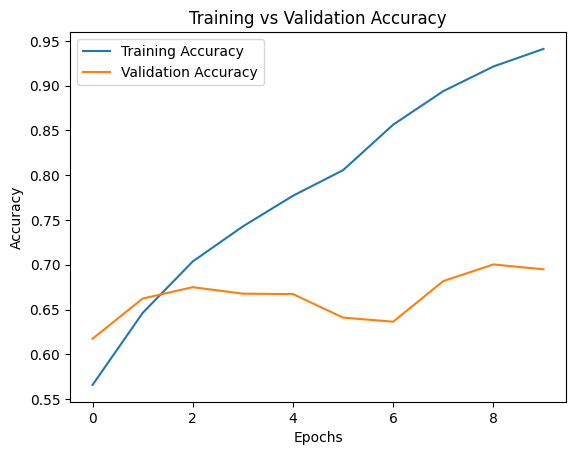

In [53]:
import matplotlib.pyplot as plt

# Plot akurasi
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()


11. Pie Chart untuk Distribusi Kelas

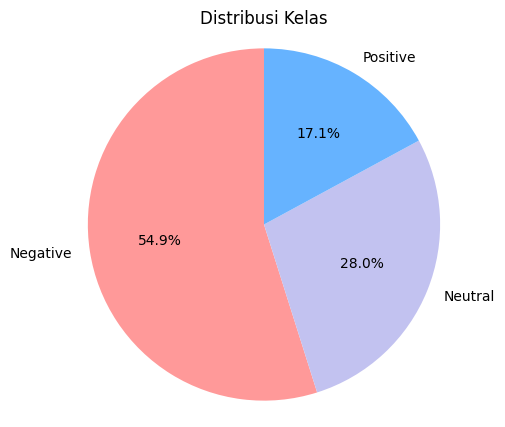

In [54]:
# Hitung jumlah masing-masing kelas
class_counts = df['label'].value_counts()
labels = ['Negative', 'Neutral', 'Positive']
colors = ['#ff9999', '#c2c2f0', '#66b3ff']

# Plot pie chart
plt.figure(figsize=(5, 5))
plt.pie(class_counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Distribusi Kelas')
plt.axis('equal')
plt.show()


12. WordCloud untuk Setiap Kelas

In [55]:
# Ubah semua elemen di kolom teks menjadi string
df['teks'] = df['teks'].fillna("").astype(str)


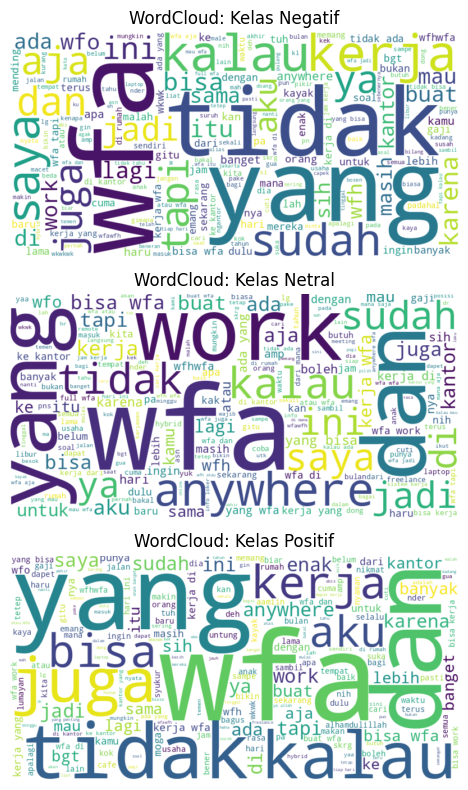

In [56]:
from wordcloud import WordCloud

# Pisahkan teks berdasarkan kelas
negative_texts = ' '.join(df[df['label'] == 0]['teks'])
neutral_texts = ' '.join(df[df['label'] == 1]['teks'])
positive_texts = ' '.join(df[df['label'] == 2]['teks'])

# WordCloud untuk setiap kelas
negative_wc = WordCloud(width=800, height=400, background_color='white').generate(negative_texts)
neutral_wc = WordCloud(width=800, height=400, background_color='white').generate(neutral_texts)
positive_wc = WordCloud(width=800, height=400, background_color='white').generate(positive_texts)

# Plot WordCloud
plt.figure(figsize=(8, 8))

# Kelas Negatif
plt.subplot(3, 1, 1)
plt.imshow(negative_wc, interpolation='bilinear')
plt.title('WordCloud: Kelas Negatif')
plt.axis('off')

# Kelas Netral
plt.subplot(3, 1, 2)
plt.imshow(neutral_wc, interpolation='bilinear')
plt.title('WordCloud: Kelas Netral')
plt.axis('off')

# Kelas Positif
plt.subplot(3, 1, 3)
plt.imshow(positive_wc, interpolation='bilinear')
plt.title('WordCloud: Kelas Positif')
plt.axis('off')

plt.tight_layout()
plt.show()
